# Tugas Mandiri Pertemuan 3 — Praktikum Big Data
**Nama:** Angger Naufal Abror

**NIM:** 2505060020

**Mata Kuliah:** Praktikum Big Data — Universitas Tidar

A. Membangun Struktur Direktori HDFS (bobot 15%)

Buatlah struktur direktori berikut di HDFS:

1. /user/[username]/ecommerce/raw
2. /user/[username]/ecommerce/processed
   
Tampilkan hasilnya untuk membuktikan struktur sudah terbentuk.


In [12]:
!hdfs dfs -mkdir -p /user/angger/ecommerce/raw

In [6]:
!hdfs dfs -mkdir -p /user/angger/ecommerce/processed

In [4]:
!hdfs dfs -ls /user/angger/ecommerce

Found 2 items
drwxr-xr-x   - angger supergroup          0 2026-09-03 13:08 /user/angger/ecommerce/processed
drwxr-xr-x   - angger supergroup          0 2026-09-03 13:18 /user/angger/ecommerce/raw


B. Mengunggah Data Mentah ke HDFS (bobot 15%)

Unggah ketiga berkas CSV (transaksi_magelang.csv, transaksi_yogyakarta.csv, transaksi_semarang.csv) ke direktori /user/[username]/ecommerce/raw di HDFS. Tampilkan isi direktori tersebut sebagai bukti ketiga berkas berhasil terunggah, lengkap dengan ukurannya.

In [15]:
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/angger/ecommerce/raw/

In [9]:
!hdfs dfs -ls -h /user/angger/ecommerce/raw

Found 3 items
-rw-r--r--   1 angger supergroup     12.0 K 2026-09-03 13:18 /user/angger/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 angger supergroup     11.9 K 2026-09-03 13:18 /user/angger/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 angger supergroup     12.4 K 2026-09-03 13:18 /user/angger/ecommerce/raw/transaksi_yogyakarta.csv


C. Membaca Kembali dan Menggabungkan Data dari HDFS (bobot 25%)

Menggunakan Python, baca kembali ketiga berkas dari HDFS (bukan dari disk lokal!). Gabungkan ketiganya menjadi satu DataFrame, lalu buktikan hasil gabungan berisi transaksi dari ketiga kota (tampilkan value_counts() pada kolom kota).

In [12]:
import io
import subprocess
import pandas as pd

files = [
    "/user/angger/ecommerce/raw/transaksi_magelang.csv",
    "/user/angger/ecommerce/raw/transaksi_yogyakarta.csv",
    "/user/angger/ecommerce/raw/transaksi_semarang.csv"
]

def baca_csv(hdfs_path):
    cmd = f"hdfs dfs -cat {hdfs_path}"
    csv_data = subprocess.check_output(cmd, shell=True)
    return pd.read_csv(io.BytesIO(csv_data))

df_list = [baca_csv(f) for f in files]
df_combined = pd.concat(df_list, ignore_index=True)

print(df_combined['kota'].value_counts())

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


D. Mengolah dan Download Hasil ke Direktori processed (bobot 25%)

Pada DataFrame gabungan hasil bagian C:

1. Tambahkan kolom total_pendapatan (unit_terjual x harga_satuan).
2. Buatlah satu tabel ringkasan (groupby) yang menampilkan total pendapatan per kota dan per kategori sekaligus.
3. Simpan dua hasil berikut sebagai berkas CSV baru di disk lokal, lalu unggah keduanya ke /user/[username]/ecommerce/processed di HDFS:
data_gabungan_bersih.csv (seluruh data ketiga kota yang telah digabung + kolom total_pendapatan)
ringkasan_kota_kategori.csv (tabel ringkasan dari langkah 2)

In [25]:
df_combined['total_pendapatan'] = df_combined['unit_terjual'] * df_combined['harga_satuan']
print("<========== 5 Baris Pertama Data Gabungan + Total Pendapatan ==========>\n")
print(df_combined.head())

ringkasan = df_combined.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()
print("\n<========== Ringkasan ==========>\n")
print(ringkasan)

df_combined.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

!hdfs dfs -mkdir -p /user/angger/ecommerce/processed

!hdfs dfs -put -f data_gabungan_bersih.csv /user/angger/ecommerce/processed
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/angger/ecommerce/processed

!hdfs dfs -ls -h /user/angger/ecommerce/processed

<========== 5 Baris Pertama Data Gabungan + Total Pendapatan ==========>

   order_id     tanggal      kategori  unit_terjual  harga_satuan  \
0  MAG-2000  2026-08-12       Fashion             1         50000   
1  MAG-2001  2026-08-18    Elektronik             7         25000   
2  MAG-2002  2026-08-07    Elektronik             7         25000   
3  MAG-2003  2026-08-24  Rumah Tangga             6         25000   
4  MAG-2004  2026-08-30       Fashion             7        100000   

  metode_pembayaran      kota  total_pendapatan  
0     Transfer Bank  Magelang             50000  
1               COD  Magelang            175000  
2          E-Wallet  Magelang            175000  
3               COD  Magelang            150000  
4     Transfer Bank  Magelang            700000  

<========== Ringkasan ==========>

          kota                kategori  total_pendapatan
0     Magelang              Elektronik          18775000
1     Magelang                 Fashion          27750000
2   

E. Dokumentasi dan Refleksi (bobot 20%)

Sertakan pada notebook anda:

1. Screenshot halaman NameNode Web UI (http://localhost:9870, menu Utilities → Browse the file system) yang menunjukkan struktur folder /user/[username]/ecommerce/ beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
2. Tulisan reflektif (minimal 100 kata) pada markdown cell yang menjawab: Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

Halaman awal NameNode WEB UI

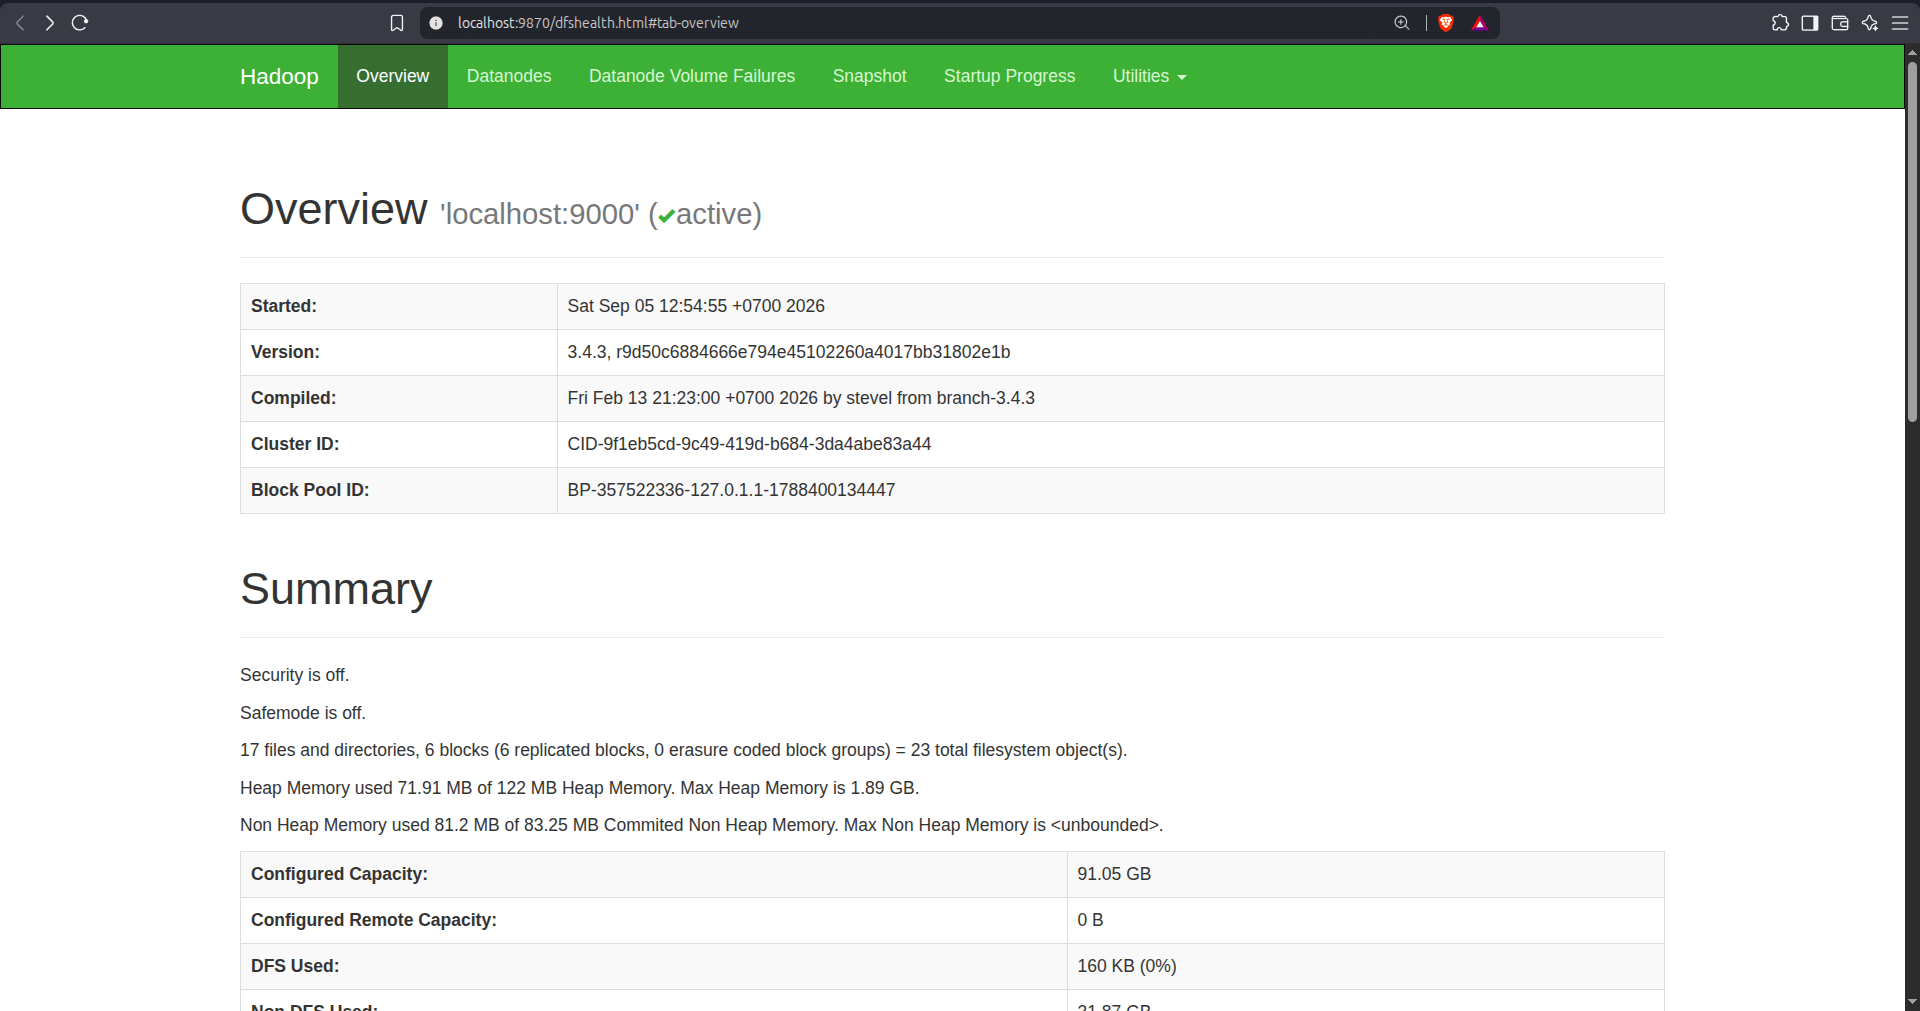

Masuk ke Utilities lalu browse the file system

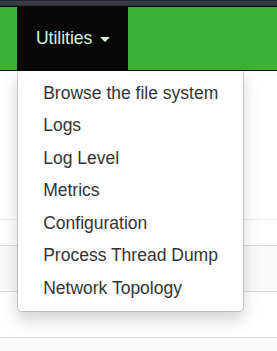

Isi folder system

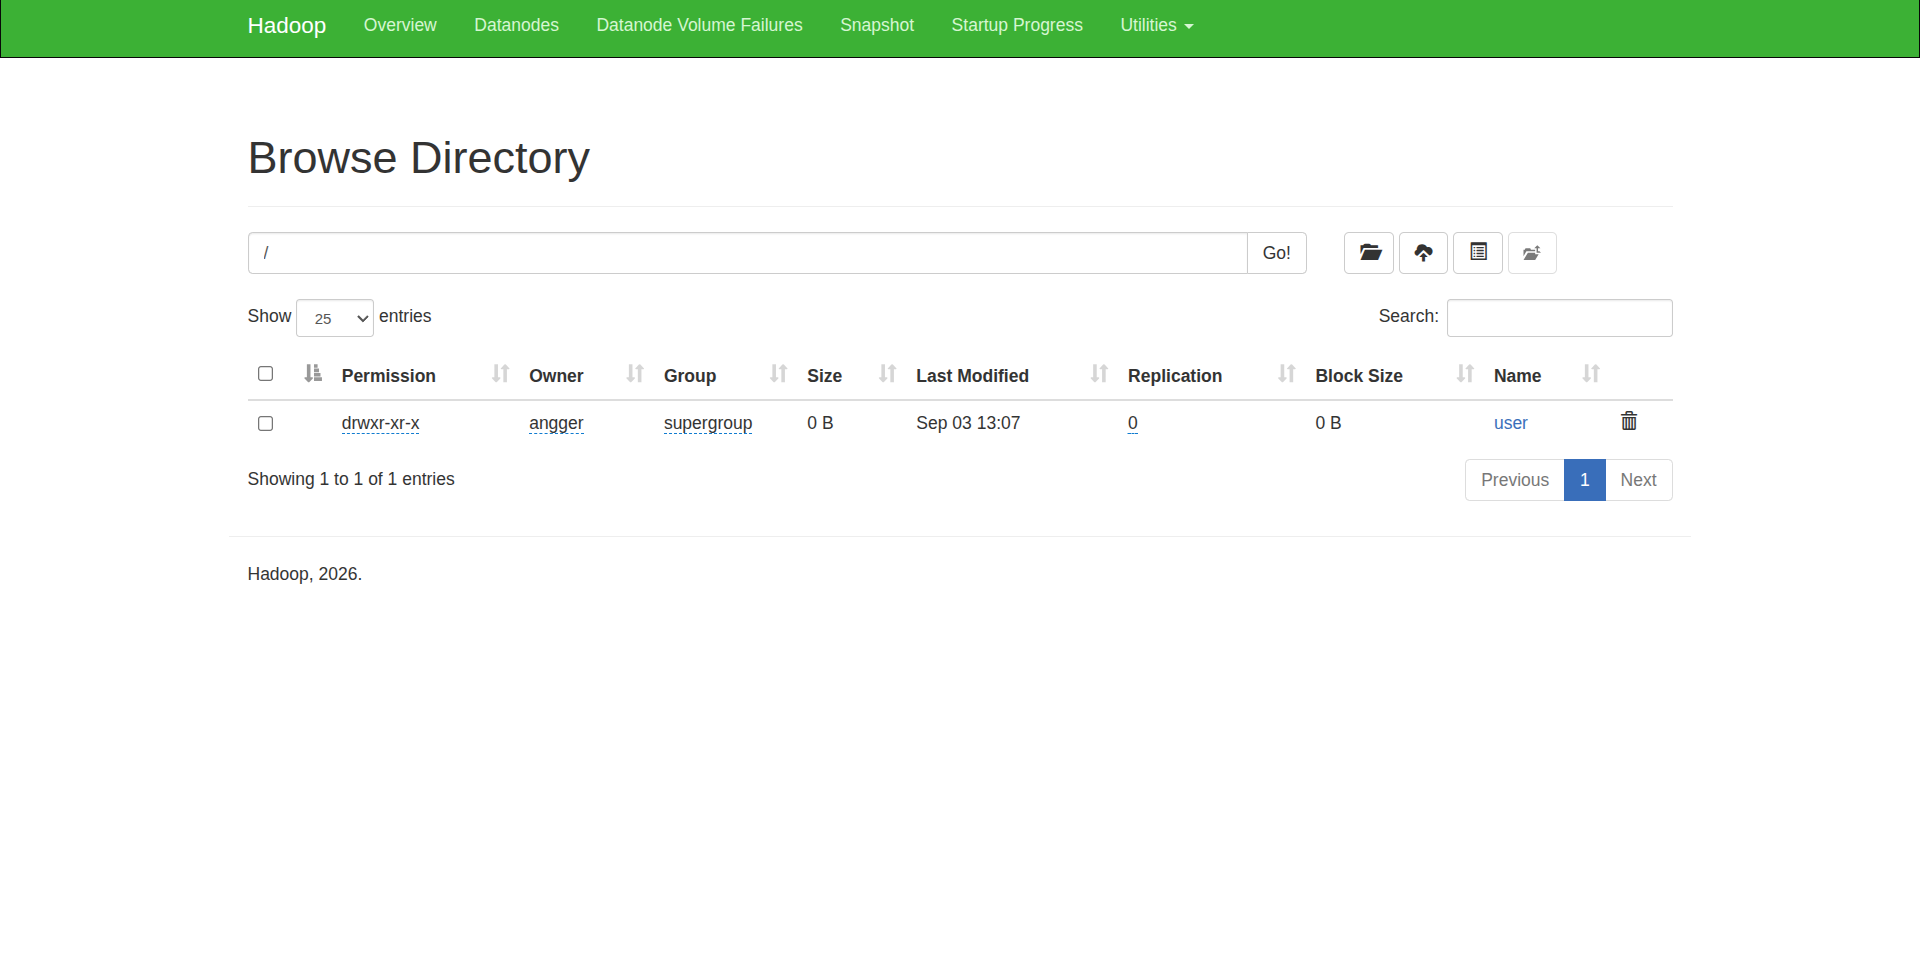

Isi folder user

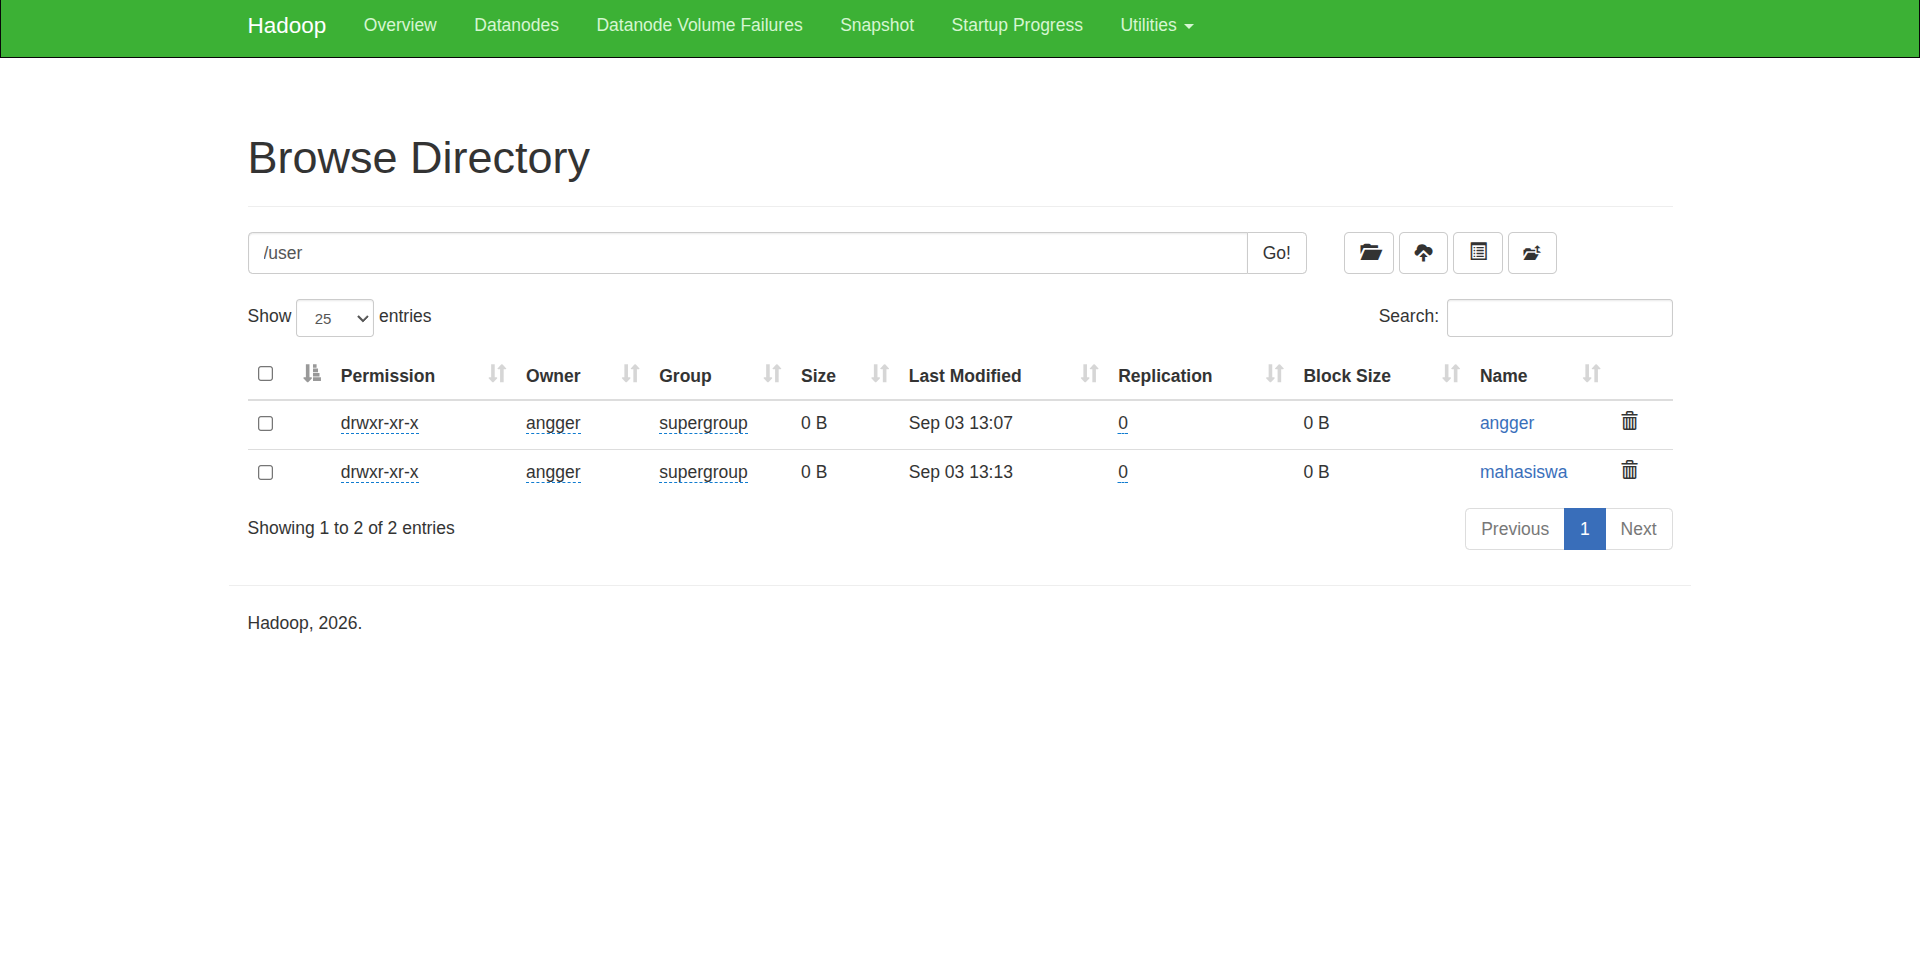

Masuk ke angger, berikut isinya

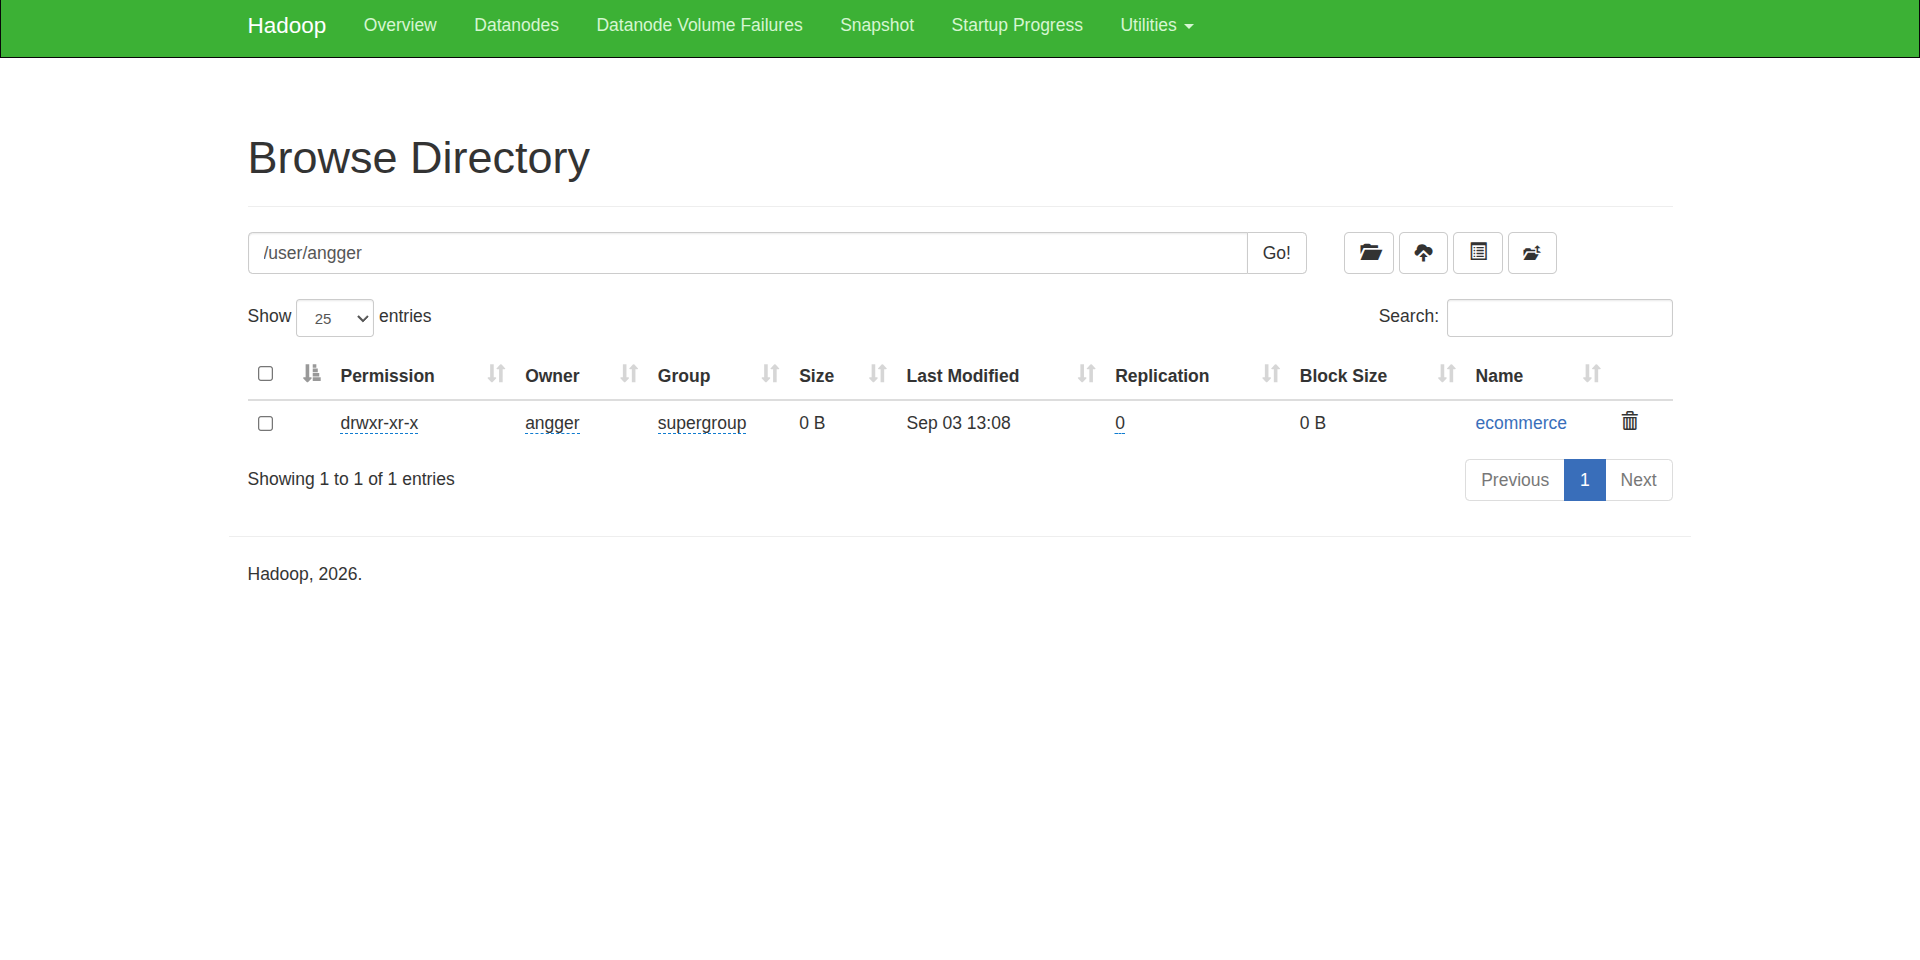

Isi ecommerce

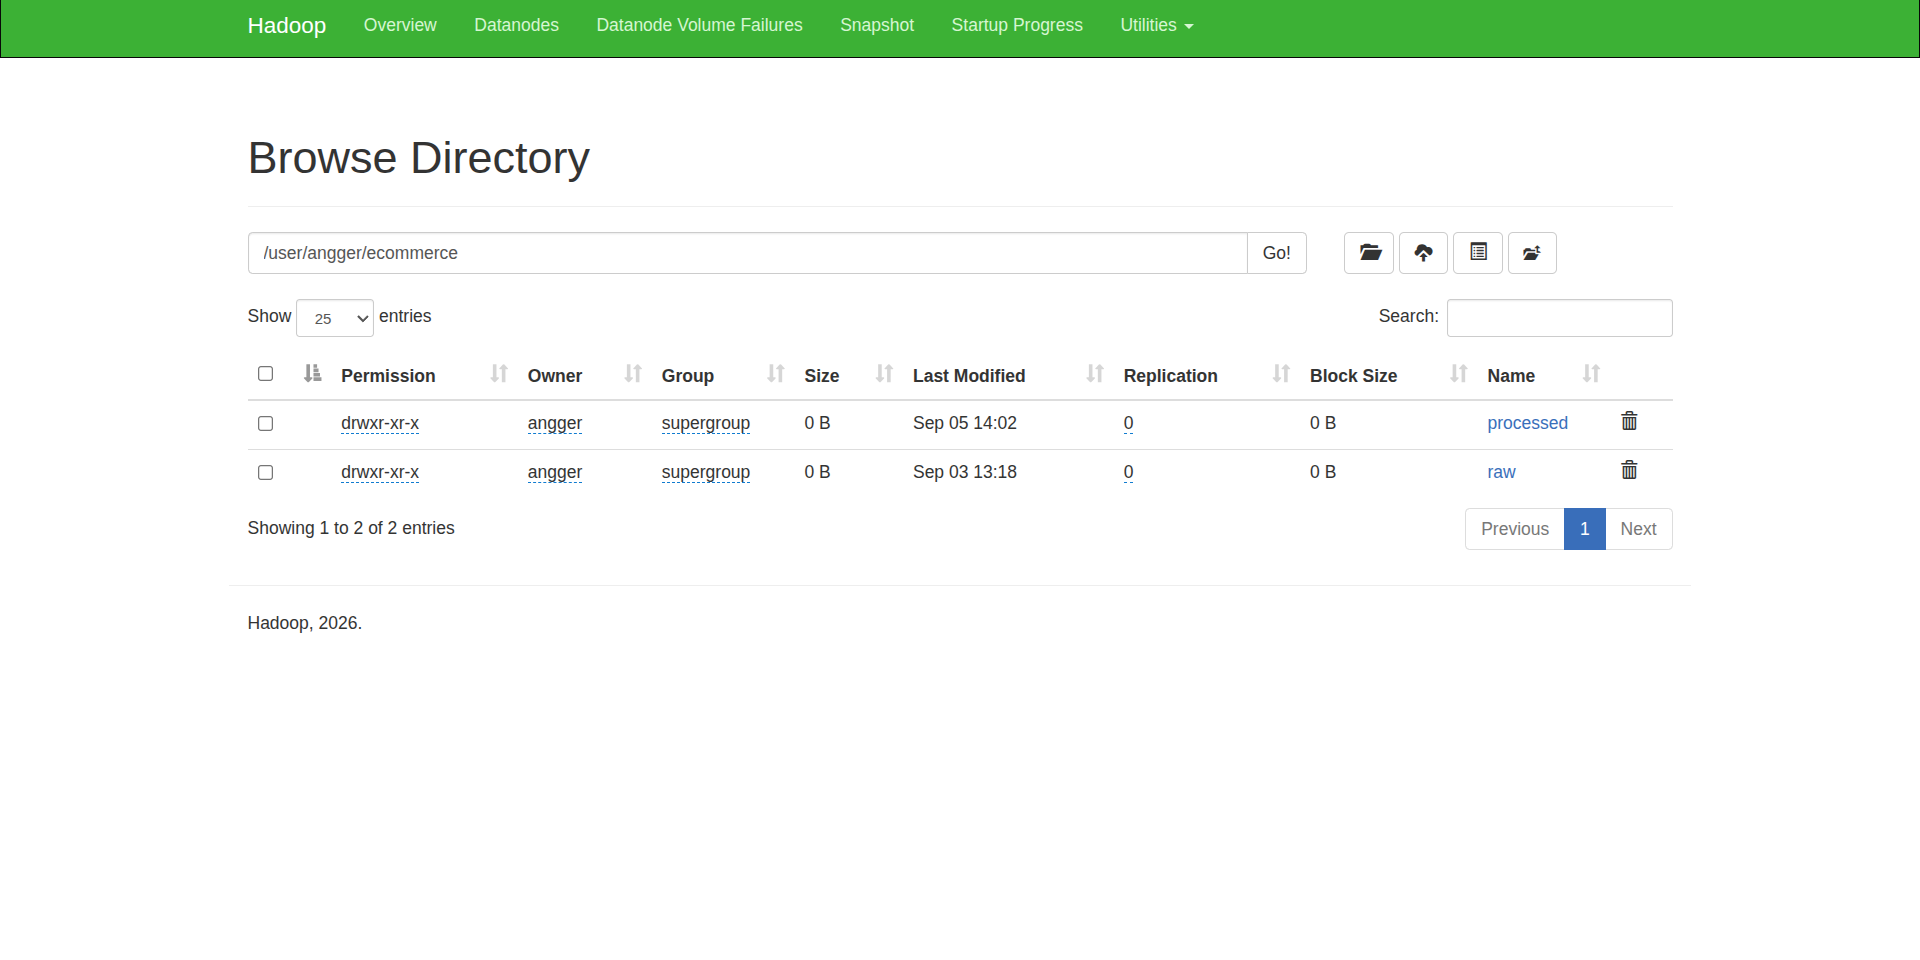

Isi data mentah (raw)

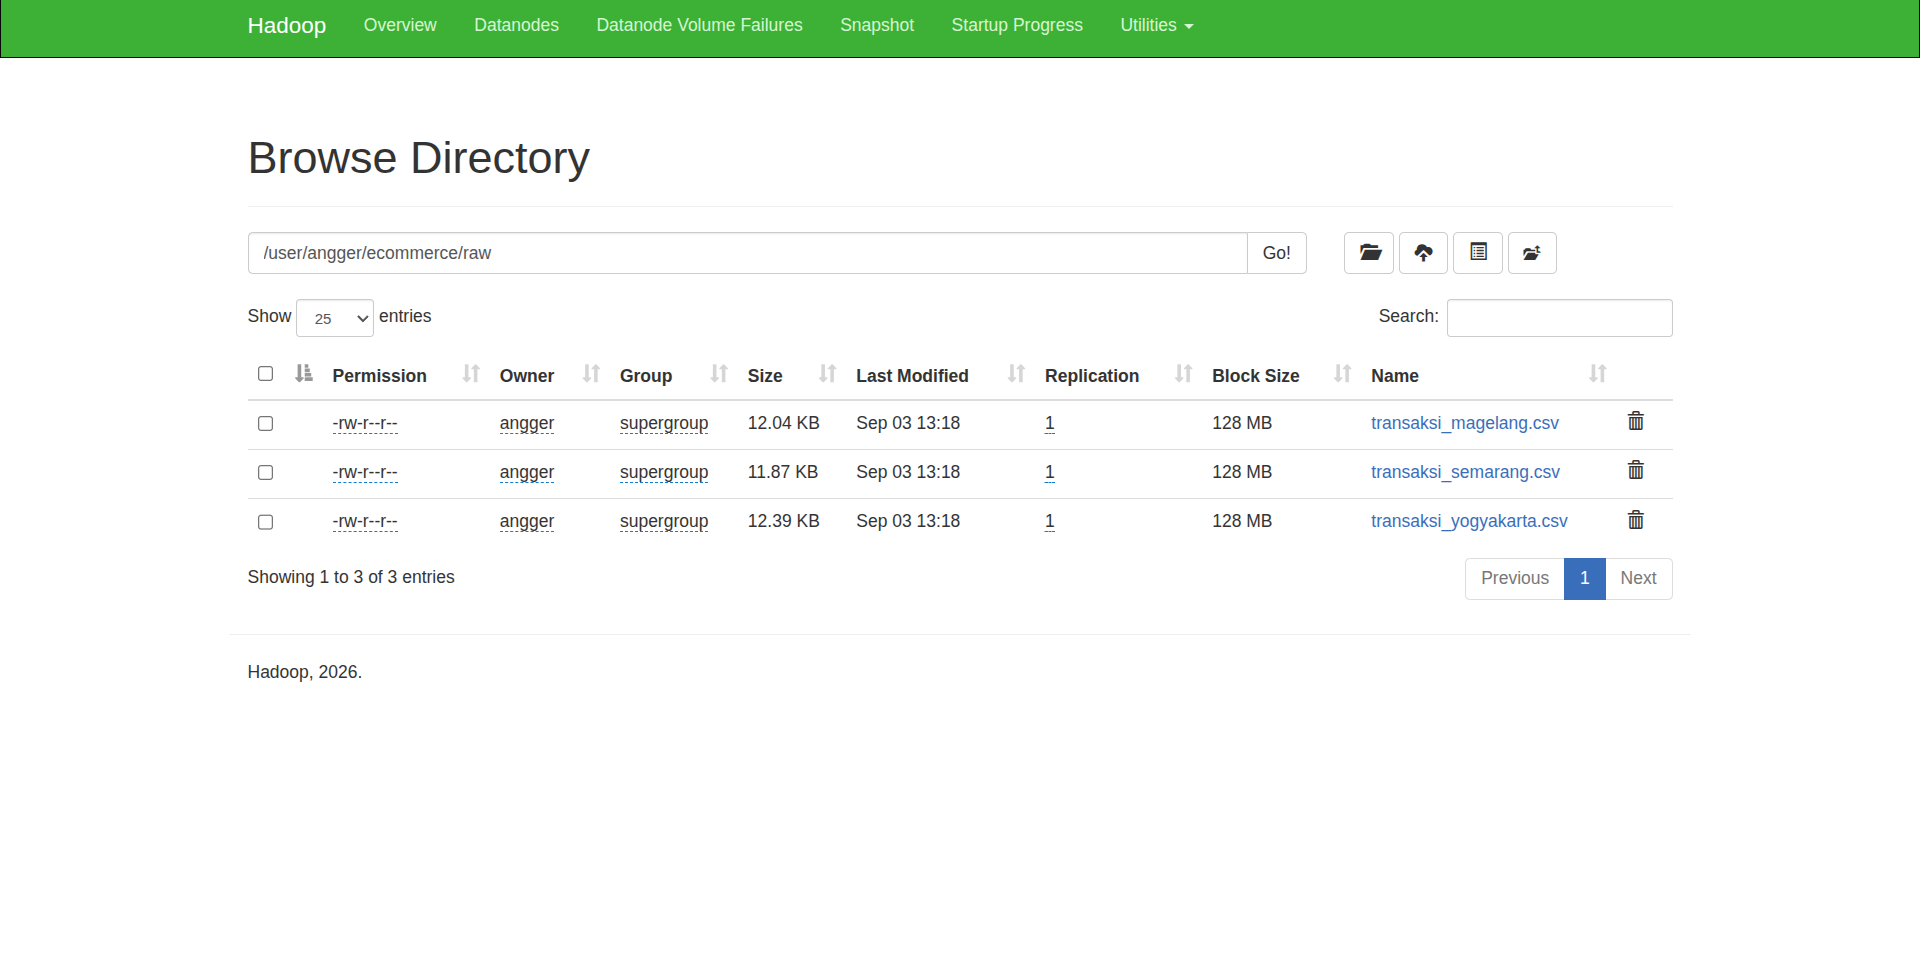

Isi data yang sudah diolah (processed)

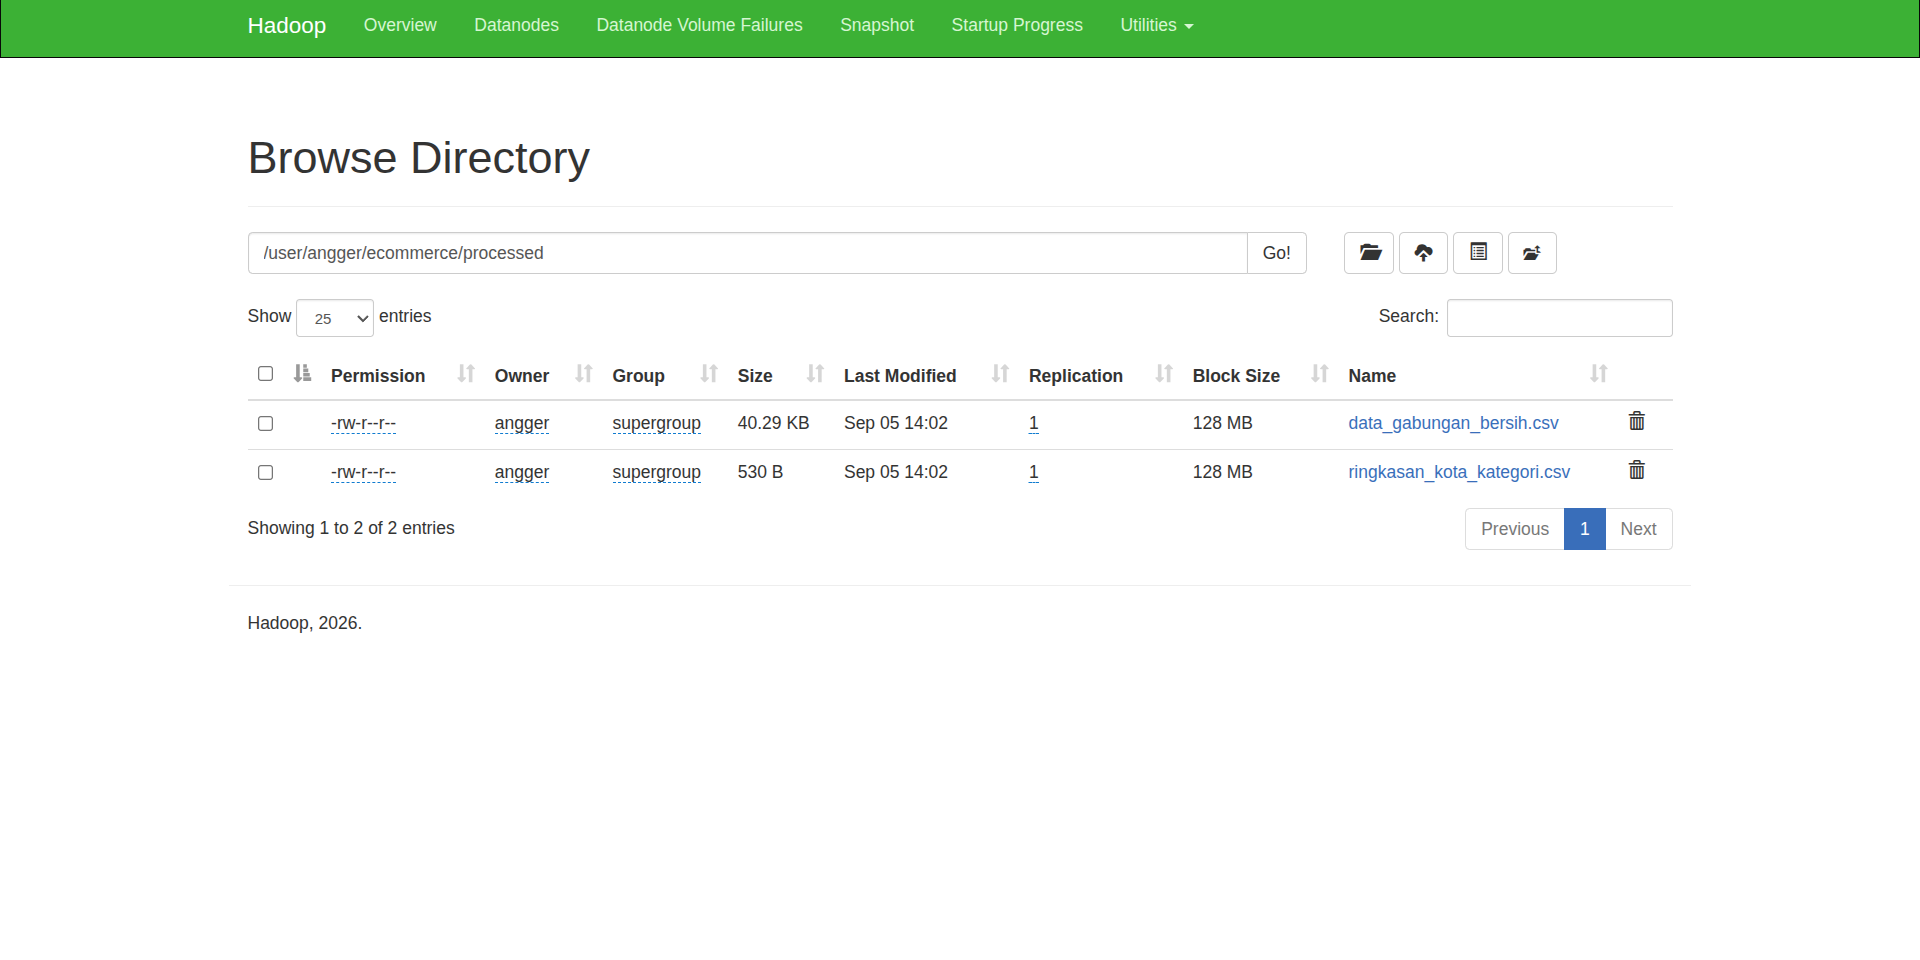

**Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?**

Jadi, kenapa penyimpanan datanya dipisah menjadi raw dan processed? hal ini dilakukan sebagai bentuk perlindungan data, data yang disimpan adalah data asli(single source of truth). 
Hal ini juga menjadikan pengaturan hak akses menjadi effisien. 
Dengan dipisahnya data mentah dan yang sudah diproses, dapat mempermudah maintenance sistem karena proses data ipeline menjadi transparan.